# Thermodynamic analysis of strategy enabling anaerobic production of PHB

In this script, we have performed the MDF analyses for the thermodynamic investigation of the NOG+EMP pathway in comparison to other strategies enabling PHB production, also demonstrating how the analysis of other pathways and metabolic engineering strategies could be analyzed by other researchers with the custom-made functions we have developed in this study.

In [1]:
from equilibrator_api import Q_ #for creating quantity variables
import equilibrator_custom_functions as eq #custom functions created during analysis
import numpy as np #numerical package
import math
import matplotlib.pyplot as plt #plotting package
import custom_plot_functions as cpf

# Input Files and their formats

The script's input is based on the two custom __input csv files__, which are:

   __The compound file__, with metabolite names, IDs and bounds. It is currently name "metabolite_reference_table"
   
   This file uses a custom csv file format, which contains information of multiple metabolites, to create a dictionary which will be used for the eQuilibrator API for high throughput analysis. This dictionary allows for writing reactions in a simpler way (with acronyms), and customizing the ranges of metabolites according to data. The columns contain the following elements:

| Metabolite Acronym        | keggID                          | Lower Bound (M)             | Upper Bound (M)               |
|------------------|----------------------------------|----------------------|------------------------|
|Custom-defined name for metabolite| Kegg ID to identify metabolite (necessary to use specific kegg ID) | Custom-defined minimal concentration (in M)| Custom-defined maximal concentration (in M) |

Notice that the column names do not need to be mantained in order to be recognized in the script. More usefull information can be added to the other columns, as the script will ignore the information stored in these.

   __The pathway file__, with reaction names, formulae, fluxes, and, in the case of ECM, enzyme parameters (which will be read by other functions below). Being pathway specific, there are many files referenced in this script. The columns contain the follow basic setup:
   
| Reaction Formula        | Relative Flux                          | Reaction Name  |     Standard dG (kJ/mol)        | kcrf(1/s) | MWe(Da)        | kM(mM) |
|------------------|----------------------------------|----------------------|------------------------|-----------------|-------|-----|
|Using the acronyms defined in the compound file: S1 + S2 <=> P1 + P2| The relative stoichiometric coefficient of the reaction in the pathway | Customizable name to identify the reaction in graphs, for example | __(Optional)__ Standard Gibs Free Energy of Reaction in kJ/mol. These are custom values that can replace the values obtained from the eQuilibrator packages|__(Only needed for ECM)__ Forward catalytic rate of reaction's enzyme in 1/s (mind the direction of the reaction) |__(Only needed for ECM)__ Enzyme molecular weight, equivalent to Daltons |__(Only needed for ECM)__ Michaelis costants of each substrate and product (except water) in milimolar, with format example 'S1: 0.1 S2:0.02 P1:3 P2:0.3' | 

# Setting Intracellular Conditions

Below we set the intracellular conditions in *E. coli*, i.e the pH, ionic strengh, temperature and pMg (which have an effect on the thermodynamics of reactions). Note that metabolite concentration bounds are also organism specific, but are defined in the compound file.

In the cell bellow the name of the compound csv file is defined __("metabolite_reference_table")__. With the function __eq.obtain_compound_settings( string: compound_file_name )__, we construct a __CompoundSettings__ object containing data structures for idetifying compounds and setting their maximal and minimal concentrations for the model)

With __eq.change_bounds__ , one can create a new CompoundSettings object with specific changes in the metabolite concentration bounds.

The __eq.fix_concentrations__ function can also be used when the concentration needs to fixed at a specific concentration

In [2]:
#Setting physiological conditions as a Python dictionary
cellular_conditions = {
            "p_h": str(Q_("7.4")),
            "p_mg": str(Q_(3)),
            "ionic_strength": str(Q_('250 mM')),
            "temperature": str(Q_(20+273.15,"K")),
            "kcat_source": "fwd",
}

#Generating Compound Settings with the default eQuilibrator bounds
cs_default_bounds = eq.obtain_compound_settings("input_metabolite_ranges_default", custom_bounds = True)
import warnings
warnings.filterwarnings('ignore')

In [3]:
pathway_names = ['NTS_and_EMP_for_MDF']
mdf_results = dict( [ (name, eq.MDF_analysis( name, cs_default_bounds, cellular_conditions, custom_dGs = True, print_results = False,y=1)) for name in pathway_names] )

Net reaction is not balanced!


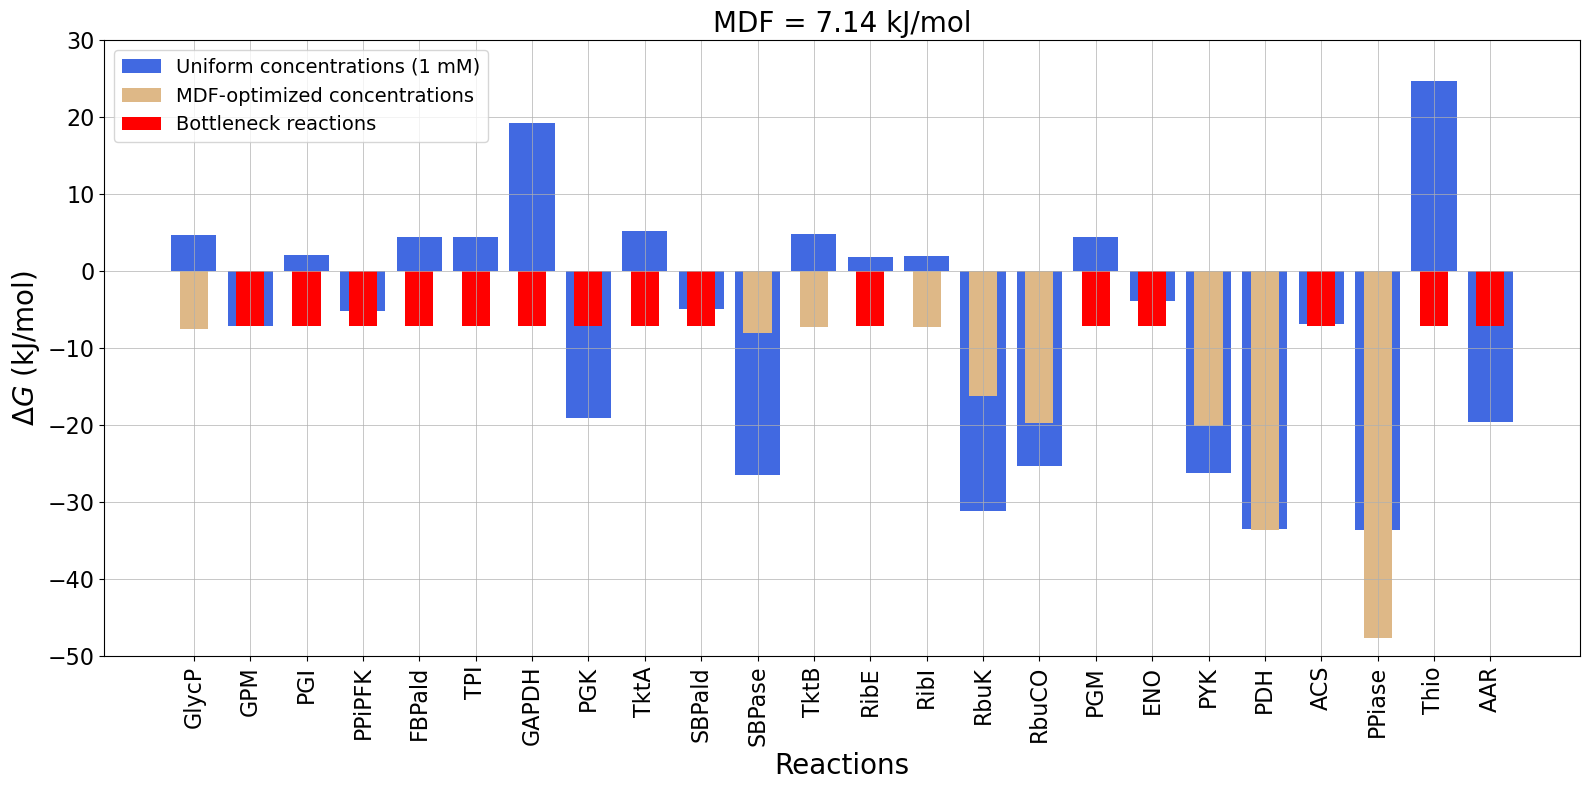

In [4]:
import matplotlib.pyplot as plt

# Create the figure and axis
fig, ax = plt.subplots(figsize=(16, 8))

# Iterate through mdf_results
for name, mdf_result in mdf_results.items():
    # Obtain necessary data
    MDF, res1, g1, g2, g3, g4, flx, shp_r, r_id, res2, met, bl, bu, c, shp_c = eq.print_MDF_results_individual(mdf_result)

    # Plot the bar chart
    cpf.plot_bar_chart(MDF, g3, g4, r_id, shp_r, ax=ax)
    #cpf.plot_concentrations_my(mdf_result)  
    #display(res1)
    #display(res2)

# Set the y-axis limit
ax.set_ylim([-50, 30])

# Set x-axis tick rotation
ax.tick_params(axis='x', rotation=90)

# Customize fonts and legend
ax.set_xlabel('Reactions', fontsize=20)  # Set x-axis label and font size
ax.set_ylabel(r'$\Delta G$ (kJ/mol)', fontsize=20)

rounded_MDF = round(MDF, 2)

ax.set_title('MDF'+' = '+str(rounded_MDF)+' kJ/mol', fontsize=20)     # Set title and font size

# Adjust the size of tick labels
ax.tick_params(axis='both', labelsize=16)  # Set font size for minor ticks on both axes

# Customize legend
legend = ax.legend(loc='upper left', fontsize=14)  # Set legend location and font size

# Adjust the position of the legend
plt.subplots_adjust(right=0.8)  # Adjust the right margin to make space for the legend

# Show the figure
plt.tight_layout()
plt.show()

# Save the figure
#fig.savefig('MDF_profile.tif', dpi=100)

In [5]:
import numpy as np
import pandas as pd

standard_dg_prime_rxns = mdf_result.reaction_df['reaction_id']
optimized_dg_prime_values = mdf_result.reaction_df['optimized_dg_prime']
numeric_values = [round(value.magnitude, 2) for value in optimized_dg_prime_values.values]

# Convert map object to a list and extract compound names
list_mets = list(standard_dg_prime_rxns)

# Extract concentrations and convert to numerical values
values_mets = numeric_values

# Convert concentrations to mM
values_mets = np.array(values_mets)

# Create a DataFrame
df = pd.DataFrame({'reactions': list_mets, 'deltaG': values_mets})

# Export DataFrame to a .txt file
df.to_csv('optimized_dGs.csv', sep='\t', index=False)

# Display DataFrame
print(df)

   reactions  deltaG
0      GlycP   -7.51
1        GPM   -7.14
2        PGI   -7.14
3     PPiPFK   -7.14
4     FBPald   -7.14
5        TPI   -7.14
6      GAPDH   -7.14
7        PGK   -7.14
8       TktA   -7.14
9     SBPald   -7.14
10    SBPase   -8.01
11      TktB   -7.30
12      RibE   -7.14
13      RibI   -7.30
14      RbuK  -16.16
15     RbuCO  -19.70
16       PGM   -7.14
17       ENO   -7.14
18       PYK  -20.12
19       PDH  -33.59
20       ACS   -7.14
21    PPiase  -47.62
22      Thio   -7.14
23       AAR   -7.14


In [6]:
import numpy as np
import pandas as pd

# Convert map object to a list and extract compound names
list_mets = list(mdf_result.compound_ids)

# Extract concentrations and convert to numerical values
values_mets = [conc.magnitude for conc in mdf_result.compound_df.concentration]

# Convert concentrations to mM
values_mets = np.array(values_mets)

#Rounding the numbers
#values_mets = np.round(values_mets, 3)

# Create a DataFrame
df = pd.DataFrame({'Compound': list_mets, 'Concentration (M)': values_mets})

# Export DataFrame to a .txt file
df.to_csv('compound_concentrations.csv', sep='\t', index=False)

# Display DataFrame
print(df)

   Compound  Concentration (M)
0       H2O           1.000000
1       ATP           0.002879
2       ADP           0.010000
3       NAD           0.010000
4        Pi           0.000187
5      NADH           0.000001
6       PPi           0.010000
7       CoA           0.000004
8       CO2           0.000156
9       AMP           0.000001
10    AcCoA           0.010000
11      PYR           0.000041
12      Ace           0.010000
13      PEP           0.000001
14      G3P           0.000023
15     DHAP           0.002409
16     Ri5P           0.000043
17      P3G           0.000424
18    AACoA           0.000066
19     Ru5P           0.000001
20      G6P           0.010000
21      X5P           0.000037
22      E4P           0.000001
23      BPG           0.000001
24      S7P           0.009283
25      P2G           0.000004
26      FBP           0.005919
27    HBCoA           0.000001
28      RBP           0.000122
29      SBP           0.000001
30     Mal4           0.008565
31      

In [7]:
import numpy as np
import pandas as pd

standard_dg_prime_rxns = mdf_result.reaction_df['reaction_id']
standard_dg_prime_values = mdf_result.reaction_df['standard_dg_prime']
numeric_values = [round(value.magnitude, 2) for value in standard_dg_prime_values.values]

# Convert map object to a list and extract compound names
list_mets = list(standard_dg_prime_rxns)

# Extract concentrations and convert to numerical values
values_mets = numeric_values

# Convert concentrations to mM
values_mets = np.array(values_mets)

# Create a DataFrame
df = pd.DataFrame({'reactions': list_mets, 'deltaG': values_mets})

# Export DataFrame to a .txt file
df.to_csv('standard_dGs.csv', sep='\t', index=False)

# Display DataFrame
print(df)

   reactions  deltaG
0      GlycP    4.69
1        GPM   -7.14
2        PGI    2.07
3     PPiPFK   -5.19
4     FBPald   21.57
5        TPI    4.41
6      GAPDH    2.17
7        PGK  -19.04
8       TktA    5.29
9     SBPald  -22.07
10    SBPase   -9.38
11      TktB    4.85
12      RibE    1.80
13      RibI    2.00
14      RbuK  -31.16
15     RbuCO  -25.26
16       PGM    4.51
17       ENO   -3.80
18       PYK  -26.26
19       PDH  -33.53
20       ACS   -6.87
21    PPiase  -16.51
22      Thio   24.76
23       AAR  -19.57


In [8]:
#from equilibrator_api import Q_ #for creating quantity variables
import equilibrator_custom_functions_my as eq #custom functions created during analysis
import numpy as np #numerical package
import math
import matplotlib.pyplot as plt #plotting package
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.axes_grid1 import ImageGrid

import custom_plot_functions as cpf

# if more space is required
from IPython.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))
display(HTML("<style>div.output_scroll {height: 50em; }</style>"))

# set defaults for plotting - grid on, linewidth = 2
plt.rc( 'axes', grid=True  )
plt.rc( 'figure', figsize = (7,4), dpi=96)
plt.rc( 'axes', linewidth=1 )
plt.rc( 'lines', linewidth=2 )

In [9]:
conc_NADH = cs_default_bounds.get_bounds('NADH',bound_type = 'upper')
conc_NAD = cs_default_bounds.get_bounds('NAD',bound_type = 'upper')

conc_ATP = cs_default_bounds.get_bounds('ATP',bound_type = 'upper')
conc_ADP = cs_default_bounds.get_bounds('ADP',bound_type = 'upper')

#total_NAD_conc = conc_NADH + conc_NAD
#total_ATPADP_conc = conc_ATP + conc_ADP

total_NAD_conc = 0.010
total_ATPADP_conc = 0.010

nn = 40
ATP_ratio_range = np.logspace(-3,3,nn)#(-3,3,7)
NAD_ratio_range = np.logspace(-3,3,nn)#(-4,2,7)

In [10]:
ATP_tuple = ('ATP','ADP',ATP_ratio_range,total_ATPADP_conc)
NAD_tuple = ('NADH','NAD',NAD_ratio_range,total_NAD_conc)
mdfs_EMP, results = eq.MDF_double_ratio_sweep(ATP_tuple,NAD_tuple,"EMP",cs_default_bounds,cellular_conditions, custom_dGs = True, y=0)
mdfs_NTS, results = eq.MDF_double_ratio_sweep(ATP_tuple,NAD_tuple,"NTS",cs_default_bounds,cellular_conditions, custom_dGs = True, y=0)
mdfs_RS, results = eq.MDF_double_ratio_sweep(ATP_tuple,NAD_tuple,"RS",cs_default_bounds,cellular_conditions, custom_dGs = True, y=0)

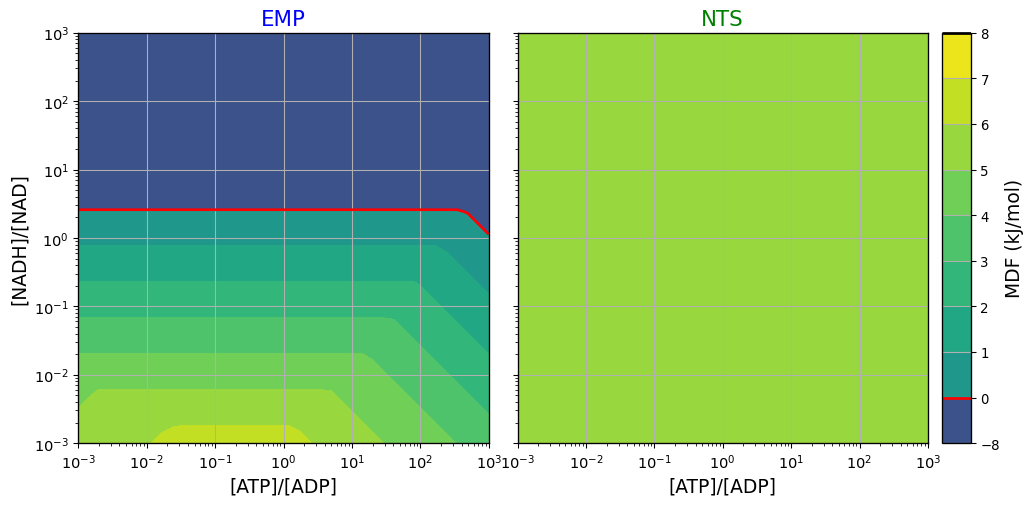

In [11]:
fig = plt.figure(figsize=(12, 6))
X, Y = np.meshgrid(ATP_ratio_range, NAD_ratio_range)

grid = ImageGrid(fig, 111,          # as in plt.subplot(111)
                 nrows_ncols=(1, 2),
                 axes_pad=0.3,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="7%",
                 cbar_pad=0.15,
)
Z = [mdfs_EMP.T, mdfs_NTS.T]

labels = ['EMP', 'NTS']
title_colors = ['blue', 'green']  # Colors for titles
title_fontsize = 16               # Font size for titles
axis_label_fontsize = 14          # Font size for axis labels
tick_label_fontsize = 11          # Font size for tick labels

for i in [0, 1]:
    CS = grid[i].contourf(X, Y, Z[i], levels=np.array([-8, 0, 1, 2, 3, 4, 5, 6, 7, 8]))
    grid[i].set_xscale("log")
    grid[i].set_yscale("log")
    grid[i].set_xlabel('[ATP]/[ADP]', fontsize=axis_label_fontsize)
    grid[i].set_ylabel('[NADH]/[NAD]', fontsize=axis_label_fontsize)
    grid[i].set_ylim(1e-3, 1e3)
    grid[i].set_xlim(1e-3, 1e3)
    lines = grid[i].contour(CS, levels=np.array([0, 8]), colors=['r', 'black'])
    # Set title with custom color and size
    grid[i].set_title(labels[i], fontsize=title_fontsize, color=title_colors[i])
    # Customize tick label sizes
    grid[i].tick_params(axis='both', which='major', labelsize=tick_label_fontsize)

cbar = plt.colorbar(CS, cax=grid[1].cax)
grid[1].cax.set_ylabel('MDF (kJ/mol)', fontsize=axis_label_fontsize)
cbar.add_lines(lines)

fig.savefig('comparison_feasibility_spaces_EMP_and_NTS.tiff', dpi=150)
plt.show()


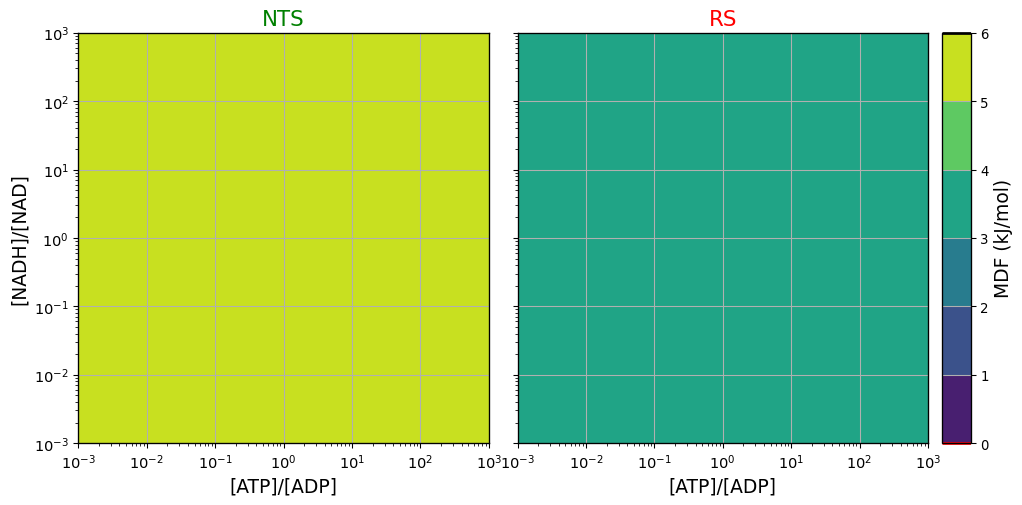

In [12]:
fig = plt.figure(figsize=(12, 6))
X, Y = np.meshgrid(ATP_ratio_range, NAD_ratio_range)

grid = ImageGrid(fig, 111,          # as in plt.subplot(111)
                 nrows_ncols=(1, 2),
                 axes_pad=0.3,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="7%",
                 cbar_pad=0.15,
)
Z = [mdfs_NTS.T, mdfs_RS.T]

labels = ['NTS', 'RS']
title_colors = ['green', 'red']  # Colors for titles
title_fontsize = 16               # Font size for titles
axis_label_fontsize = 14          # Font size for axis labels
tick_label_fontsize = 11          # Font size for tick labels

for i in [0, 1]:
    CS = grid[i].contourf(X, Y, Z[i], levels=np.array([0,1,2,3, 4, 5, 6]))
    grid[i].set_xscale("log")
    grid[i].set_yscale("log")
    grid[i].set_xlabel('[ATP]/[ADP]', fontsize=axis_label_fontsize)
    grid[i].set_ylabel('[NADH]/[NAD]', fontsize=axis_label_fontsize)
    grid[i].set_ylim(1e-3, 1e3)
    grid[i].set_xlim(1e-3, 1e3)
    lines = grid[i].contour(CS, levels=np.array([0, 8]), colors=['r', 'black'])
    # Set title with custom color and size
    grid[i].set_title(labels[i], fontsize=title_fontsize, color=title_colors[i])
    # Customize tick label sizes
    grid[i].tick_params(axis='both', which='major', labelsize=tick_label_fontsize)

cbar = plt.colorbar(CS, cax=grid[1].cax)
grid[1].cax.set_ylabel('MDF (kJ/mol)', fontsize=axis_label_fontsize)
cbar.add_lines(lines)

fig.savefig('comparison_feasibility_spaces_NTS_and_RS.tiff', dpi=150)
plt.show()
